# Personality Trait Classification from AV Interaction Behavior

Classifies participants as **High Neuroticism – Low Openness** vs **High Openness – Low Neuroticism**
from their slider interaction patterns with the autonomous driving control UI (Condition A — functional sessions only).

**Pipeline:**
1. Load functional-UI session CSVs (exclude placebo files)
2. Engineer per-participant behavioral features
3. Train classifiers with Leave-One-Out cross-validation
4. Report accuracy, F1, confusion matrix, feature importance

In [1]:
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '../collected_data'

## 1. Load Data

In [2]:
NUMERIC_COLS = [
    'Acceleration', 'Deceleration', 'Lane Offset',
    'Consider Overtake', 'Overtake',
    'Steer Trq', 'Steer Accel', 'Steer Veloc',
    'Speed', 'Lateral Acceleration'
]

def load_csv(path):
    df = pd.read_csv(path)
    drop_cols = [c for c in df.columns
                 if 'Lateral Acceleration.1' in c or c == 'file_name']
    df = df.drop(columns=drop_cols, errors='ignore')
    if 'Lateral Acceleration' in df.columns:
        df['Lateral Acceleration'] = pd.to_numeric(df['Lateral Acceleration'], errors='coerce')
    if 'Consider Overtake' in df.columns:
        df['Consider Overtake'] = df['Consider Overtake'].fillna(0)
    return df

all_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
# Exclude placebo sessions — sliders were non-functional (Condition C)
functional_files = [f for f in all_files if 'placebo' not in os.path.basename(f).lower()]

print(f'Total CSVs: {len(all_files)}')
print(f'Functional (Condition A) CSVs: {len(functional_files)}')

records = []
for fpath in functional_files:
    df = load_csv(fpath)
    if 'Personality Trait' not in df.columns:
        continue
    label_series = df['Personality Trait'].dropna()
    if label_series.empty:
        continue
    label = label_series.mode()[0]
    # Keep only clearly labelled binary classes
    if label not in ('High Neuroticism - Low Openness', 'High Openness - Low Neuroticism'):
        continue
    records.append({'file': os.path.basename(fpath), 'label': label, 'df': df})

print(f'Valid records: {len(records)}')
print()
label_counts = pd.Series([r['label'] for r in records]).value_counts()
print('Class distribution:')
print(label_counts)

Total CSVs: 34
Functional (Condition A) CSVs: 21
Valid records: 21

Class distribution:
High Neuroticism - Low Openness    12
High Openness - Low Neuroticism     9
Name: count, dtype: int64


## 2. Feature Engineering

Each participant's time-series session is summarised into a fixed-length feature vector:
- **mean, std, min, max, range** of each slider column
- **num_changes**: count of rows where slider value differs from the previous row (proxy for interaction frequency)
- **session_length**: total logged rows

In [3]:
def count_changes(series):
    return int((series.diff().fillna(0) != 0).sum())

def engineer_features(df):
    feats = {}
    for col in NUMERIC_COLS:
        if col not in df.columns:
            continue
        s = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(s) == 0:
            continue
        prefix = col.replace(' ', '_')
        feats[f'{prefix}_mean']    = s.mean()
        feats[f'{prefix}_std']     = s.std()
        feats[f'{prefix}_min']     = s.min()
        feats[f'{prefix}_max']     = s.max()
        feats[f'{prefix}_range']   = s.max() - s.min()
        feats[f'{prefix}_changes'] = count_changes(s)
    feats['session_length'] = len(df)
    return feats

feature_rows, labels, file_names = [], [], []
for r in records:
    feature_rows.append(engineer_features(r['df']))
    labels.append(r['label'])
    file_names.append(r['file'])

X_df = pd.DataFrame(feature_rows).fillna(0)
print(f'Feature matrix: {X_df.shape}')
X_df.head()

Feature matrix: (21, 61)


,Acceleration_mean,Acceleration_std,Acceleration_min,Acceleration_max,Acceleration_range,Acceleration_changes,Deceleration_mean,Deceleration_std,Deceleration_min,Deceleration_max,...,Speed_max,Speed_range,Speed_changes,Lateral_Acceleration_mean,Lateral_Acceleration_std,Lateral_Acceleration_min,Lateral_Acceleration_max,Lateral_Acceleration_range,Lateral_Acceleration_changes,session_length
0,4.803289,2.903454e-01,3.904,5.1920,1.2880,338,-4.342127,3.176868e-01,-4.8000,-3.9376,...,141.25,22.50,98,3.950000,0.000000e+00,3.9500,3.9500,0.0000,0.0,1410
1,4.630849,7.069144e-01,3.400,5.1472,1.7472,607,-4.800000,8.882588e-16,-4.8000,-4.8000,...,168.00,153.25,2376,3.950000,4.441294e-16,3.9500,3.9500,0.0000,0.0,5525
2,4.800000,8.888720e-16,4.800,4.8000,0.0000,0,-4.800000,8.888720e-16,-4.8000,-4.8000,...,151.25,89.00,269,3.950000,4.444360e-16,3.9500,3.9500,0.0000,0.0,641
3,5.138673,4.275766e-01,3.932,5.7128,1.7808,244,-4.707319,6.045726e-01,-5.5896,-3.7416,...,246.50,121.50,335,5.444572,1.449694e+00,3.3587,7.6000,4.2413,298.0,4327
4,4.855885,9.536387e-01,3.512,6.2224,2.7104,576,-4.400028,5.408817e-01,-4.8000,-3.4504,...,210.50,135.00,548,3.935753,2.999086e-01,2.0593,5.0085,2.9492,243.0,2871


In [4]:
le = LabelEncoder()
y = le.fit_transform(labels)
X = X_df.values
feature_names = X_df.columns.tolist()

print('Label encoding:', dict(zip(le.classes_, le.transform(le.classes_))))
print('N per class:', dict(zip(*np.unique(y, return_counts=True))))

Label encoding: {np.str_('High Neuroticism - Low Openness'): np.int64(0), np.str_('High Openness - Low Neuroticism'): np.int64(1)}
N per class: {np.int64(0): np.int64(12), np.int64(1): np.int64(9)}


## 3. Exploratory Feature Analysis

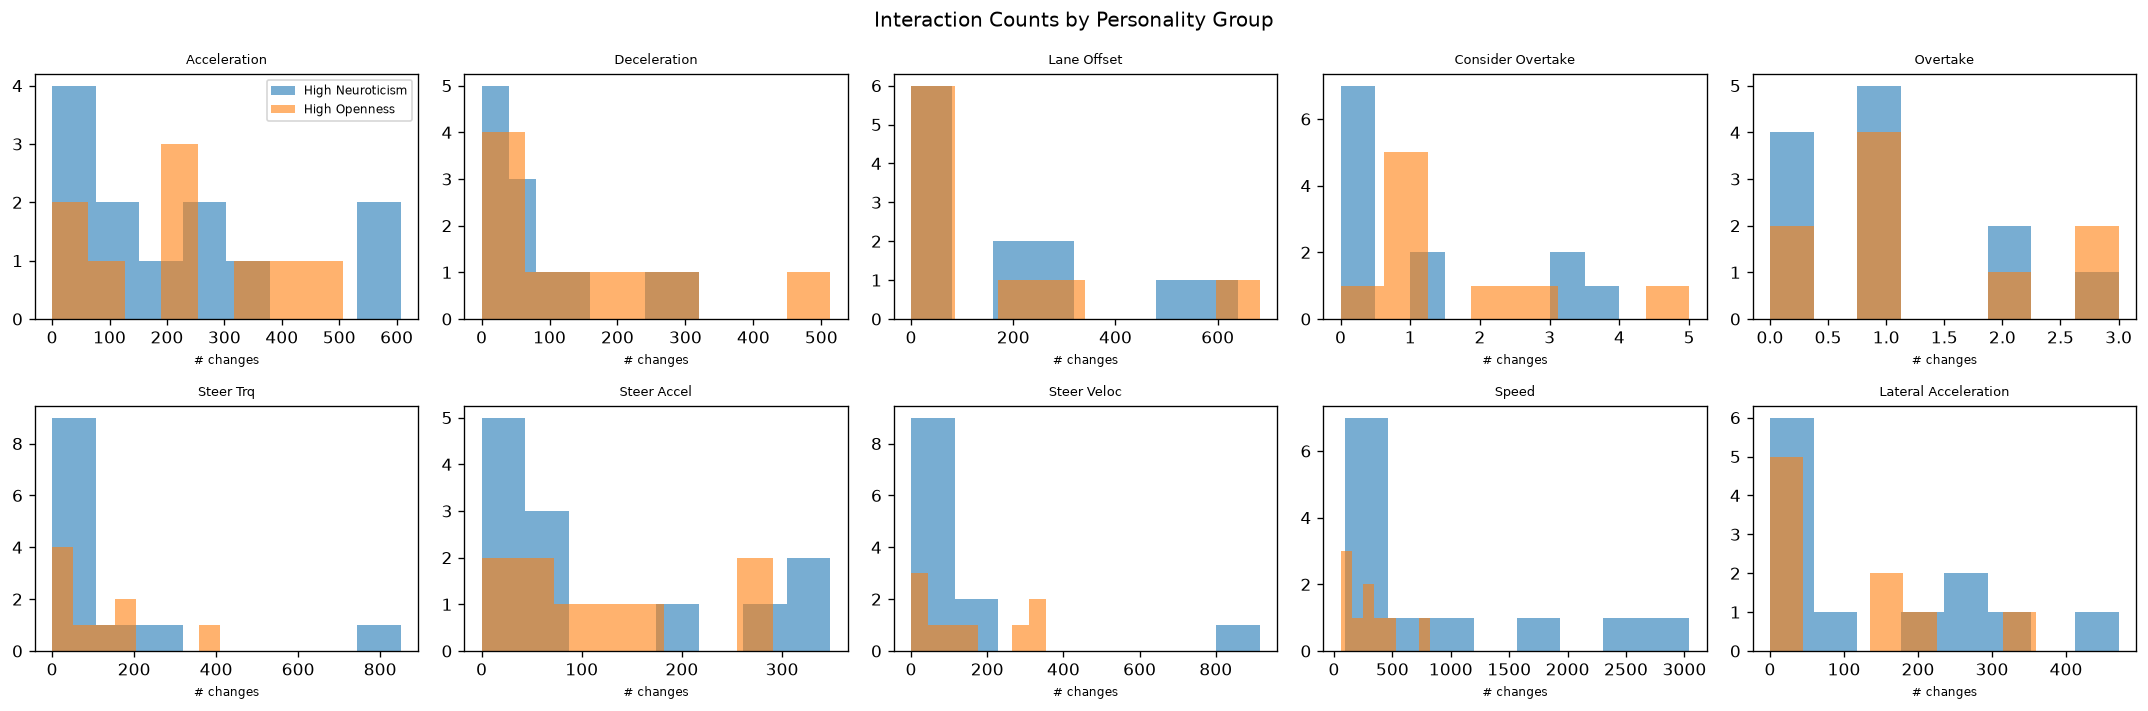

In [5]:
X_df_plot = X_df.copy()
X_df_plot['label'] = labels

change_cols = [c for c in feature_names if c.endswith('_changes')]
n = len(change_cols)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3 * nrows))
axes = axes.flatten()

for i, col in enumerate(change_cols):
    ax = axes[i]
    for lbl, grp in X_df_plot.groupby('label'):
        ax.hist(grp[col], bins=8, alpha=0.6, label=lbl.split(' - ')[0])
    ax.set_title(col.replace('_changes', '').replace('_', ' '), fontsize=8)
    ax.set_xlabel('# changes', fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=7)
plt.suptitle('Interaction Counts by Personality Group', fontsize=12)
plt.tight_layout()
plt.show()

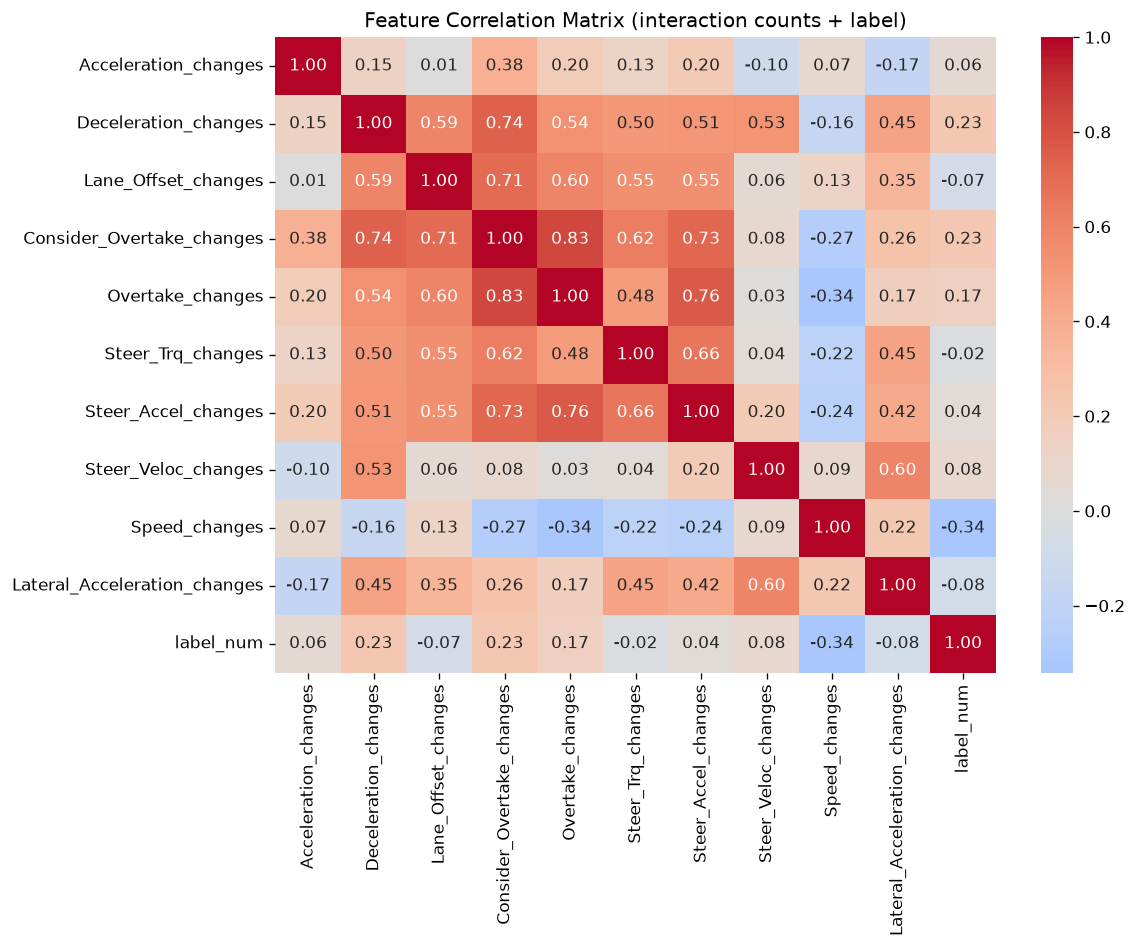

In [6]:
# Correlation heatmap of change features
fig, ax = plt.subplots(figsize=(10, 8))
corr = X_df_plot[change_cols + ['label']].copy()
corr['label_num'] = (corr['label'] == 'High Openness - Low Neuroticism').astype(int)
sns.heatmap(
    corr[change_cols + ['label_num']].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax
)
ax.set_title('Feature Correlation Matrix (interaction counts + label)')
plt.tight_layout()
plt.show()

## 4. Classification — Leave-One-Out Cross-Validation

LOO-CV is used because N is small (~20 participants). Each participant is held out once as the test set.

In [7]:
loo = LeaveOneOut()

models = {
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
    ]),
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=0.5, max_iter=500, random_state=42))
    ]),
    'KNN (k=3)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=3))
    ]),
    'Gradient Boosting': Pipeline([
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}

results = {}
for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=loo)
    acc = accuracy_score(y, y_pred)
    f1  = f1_score(y, y_pred, average='weighted')
    results[name] = {'accuracy': acc, 'f1': f1, 'y_pred': y_pred}
    print(f'{name:<25}  accuracy={acc:.3f}  f1={f1:.3f}')

best_name = max(results, key=lambda k: results[k]['f1'])
print(f'\nBest model: {best_name}')

Random Forest              accuracy=0.429  f1=0.429
SVM (RBF)                  accuracy=0.524  f1=0.393
Logistic Regression        accuracy=0.381  f1=0.375
KNN (k=3)                  accuracy=0.429  f1=0.415


Gradient Boosting          accuracy=0.286  f1=0.279

Best model: Random Forest


## 5. Detailed Evaluation of Best Model

=== Random Forest — LOO-CV Results ===
                                 precision    recall  f1-score   support

High Neuroticism - Low Openness       0.50      0.50      0.50        12
High Openness - Low Neuroticism       0.33      0.33      0.33         9

                       accuracy                           0.43        21
                      macro avg       0.42      0.42      0.42        21
                   weighted avg       0.43      0.43      0.43        21



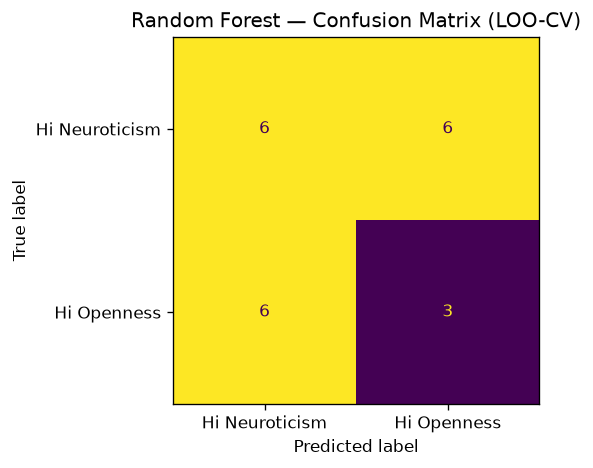

In [8]:
best_pred = results[best_name]['y_pred']

print(f'=== {best_name} — LOO-CV Results ===')
print(classification_report(y, best_pred, target_names=le.classes_))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Hi Neuroticism', 'Hi Openness'])
disp.plot(ax=ax, colorbar=False)
ax.set_title(f'{best_name} — Confusion Matrix (LOO-CV)')
plt.tight_layout()
plt.show()

## 6. Feature Importance (Random Forest)

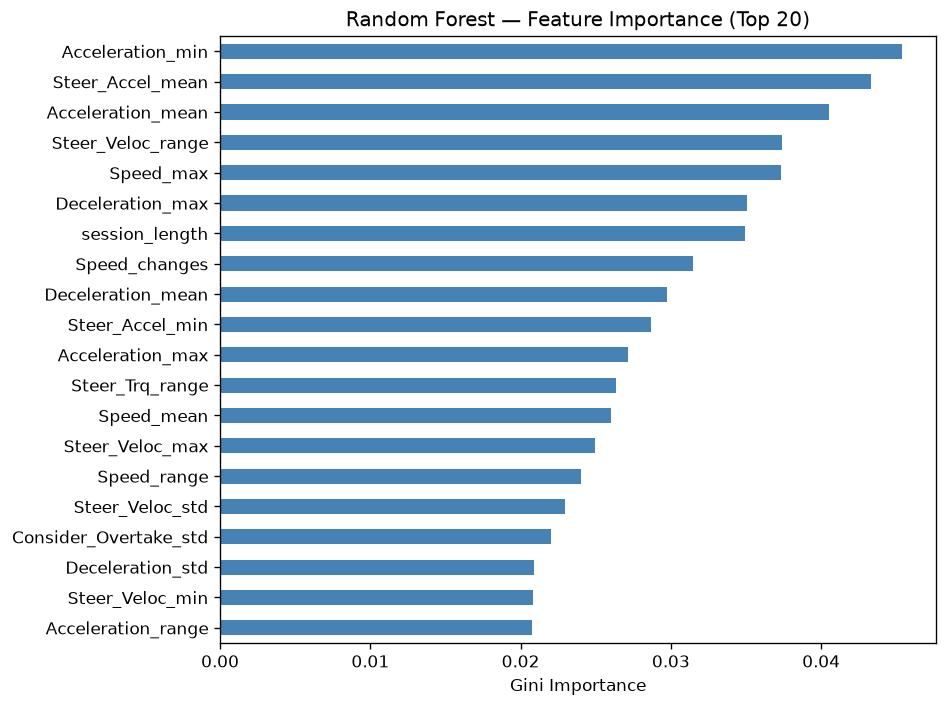

Top 10 features:
Acceleration_min     0.045371
Steer_Accel_mean     0.043294
Acceleration_mean    0.040542
Steer_Veloc_range    0.037374
Speed_max            0.037343
Deceleration_max     0.035092
session_length       0.034905
Speed_changes        0.031500
Deceleration_mean    0.029751
Steer_Accel_min      0.028677


In [9]:
rf_full = RandomForestClassifier(n_estimators=500, random_state=42)
rf_full.fit(X, y)

importances = pd.Series(rf_full.feature_importances_, index=feature_names).sort_values(ascending=True)
top20 = importances.tail(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Random Forest — Feature Importance (Top 20)')
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importances.tail(10).iloc[::-1].to_string())

## 7. Model Comparison Summary

              Model  Accuracy  F1 (weighted)
      Random Forest  0.428571       0.428571
          KNN (k=3)  0.428571       0.414835
          SVM (RBF)  0.523810       0.392857
Logistic Regression  0.380952       0.375126
  Gradient Boosting  0.285714       0.278992


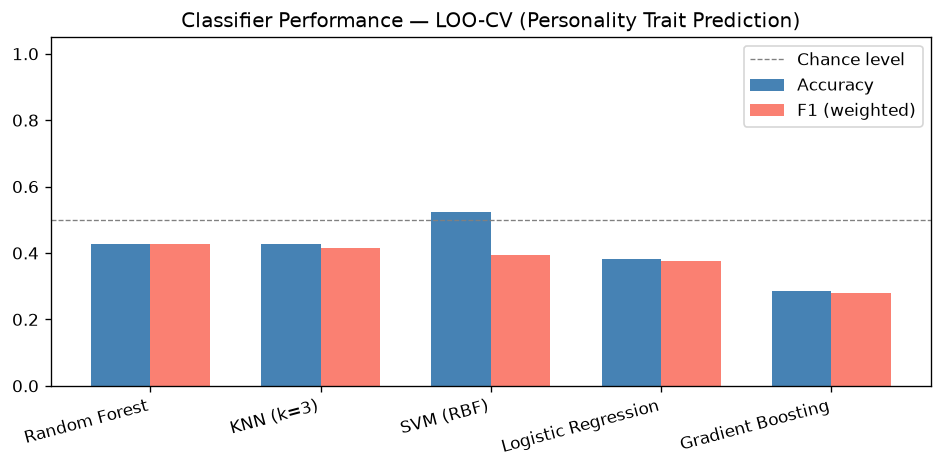

In [10]:
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[k]['accuracy'] for k in results],
    'F1 (weighted)': [results[k]['f1'] for k in results]
}).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)

print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(summary))
w = 0.35
ax.bar(x - w/2, summary['Accuracy'], w, label='Accuracy', color='steelblue')
ax.bar(x + w/2, summary['F1 (weighted)'], w, label='F1 (weighted)', color='salmon')
ax.axhline(0.5, linestyle='--', color='gray', linewidth=0.8, label='Chance level')
ax.set_xticks(x)
ax.set_xticklabels(summary['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Classifier Performance — LOO-CV (Personality Trait Prediction)')
ax.legend()
plt.tight_layout()
plt.show()